# Assignment 8: Implement a Neural Network for Sentiment Analysis

In [1]:
import pandas as pd
import numpy as np
import os 
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2" # suppress info and warning messages
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
import tensorflow.keras as keras
import time

In this assignment, you will implement a feedforward neural network that performs sentiment classification.
You will complete the following tasks:
    
1. Build your DataFrame and define your ML problem:
    * Load the book review data set
    * Define the label - what are you predicting?
    * Identify the features
2. Create labeled examples from the data set
3. Split the data into training and test data sets
4. Transform the training and test text data using a TF-IDF vectorizer. 
5. Construct a neural network
6. Train the neural network
7. Compare the neural network model's performance on the training and validation data.
8. Improve the model's generalization performance.
9. Evaluate the model's performance on the test data.
10. Experiment with ways to improve the model.

For this assignment, use the demo <i>Transforming Text into Features for Sentiment Analysis</i> that is contained in this unit as a reference.

**<font color='red'>Note: some of the code cells in this notebook may take a while to run</font>**

## Part 1. Build Your DataFrame and Define Your ML Problem


#### Load a Data Set and Save it as a Pandas DataFrame

We will work with the book review data set that contains book reviews taken from Amazon.com reviews.

<b>Task</b>: In the code cell below, use the same method you have been using to load the data using `pd.read_csv()` and save it to DataFrame `df`.

You will be working with the file named "bookReviews.csv" that is located in a folder named "data_NLP".

In [2]:
# YOUR CODE HERE

df=pd.read_csv('data_NLP/bookReviews.csv')

#### Inspect the Data

<b>Task</b>: In the code cell below, inspect the data in DataFrame `df` by printing the number of rows and columns, the column names, and the first ten rows. You may perform any other techniques you'd like to inspect the data.

In [3]:
# YOUR CODE HERE
print(df.shape)
print(df.columns)
df.head(10)

(1973, 2)
Index(['Review', 'Positive Review'], dtype='object')


,Review,Positive Review
0,This was perhaps the best of Johannes Steinhof...,True
1,This very fascinating book is a story written ...,True
2,The four tales in this collection are beautifu...,True
3,The book contained more profanity than I expec...,False
4,We have now entered a second time of deep conc...,True
5,I don't know why it won the National Book Awar...,False
6,The daughter of a prominent Boston doctor is d...,False
7,I was very disapointed in the book.Basicly the...,False
8,I think in retrospect I wasted my time on this...,False
9,I have a hard time understanding what it is th...,False


#### Define the Label

This is a binary classification problem in which we will predict whether a book review is a positive or negative one. The label is the `Positive Review` column.

#### Identify Features

We only have one feature. The feature is the `Review` column.


## Part 2. Create Labeled Examples from the Data Set 

<b>Task</b>: In the code cell below, create labeled examples from DataFrame `df`. Assign the label to the variable `y`. Assign the feature to the variable `X`. 

In [4]:
# YOUR CODE HERE
y = df['Positive Review']
X = df['Review']

## Part 3. Create Training and Test Data Sets

<b>Task</b>: In the code cell below, create training and test sets out of the labeled examples. Create a test set that is 25 percent of the size of the data set. Save the results to variables `X_train, X_test, y_train, y_test`.


In [5]:
# YOUR CODE HERE
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25,random_state=123)

## Part 4:  Implement TF-IDF Vectorizer to Transform Text


In the code cell below, you will transform the features into numerical vectors using `TfidfVectorizer`. 


<b>Task:</b> Follow the steps to complete the code in the cell below:

1. Create a `TfidfVectorizer` object and save it to the variable `tfidf_vectorizer`.

2. Call `tfidf_vectorizer.fit()` to fit the vectorizer to the training data `X_train`.

3. Call the `tfidf_vectorizer.transform()` method to use the fitted vectorizer to transform the training data `X_train`. Save the result to `X_train_tfidf`.

4. Call the `tfidf_vectorizer.transform()` method to use the fitted vectorizer to transform the test data `X_test`. Save the result to `X_test_tfidf`.

In [6]:
# 1. Create a TfidfVectorizer object 
# YOUR CODE HERE
tfidf_vectorizer = TfidfVectorizer()

# 2. Fit the vectorizer to X_train
# YOUR CODE HERE
tfidf_vectorizer.fit(X_train)

# 3. Using the fitted vectorizer, transform the training data 
# YOUR CODE HERE
X_train_tfidf = tfidf_vectorizer.transform(X_train)

# 4. Using the fitted vectorizer, transform the test data 
# YOUR CODE HERE
X_test_tfidf = tfidf_vectorizer.transform(X_test)

When constructing our neural network, we will have to specify the `input_shape`, meaning the dimensionality of the input layer. This corresponds to the dimension of each of the training examples, which in our case is our vocabulary size. Run the code cell below to see the vocabulary size.


In [7]:
vocabulary_size = len(tfidf_vectorizer.vocabulary_)

print(vocabulary_size)

18484


## Part 5: Construct a Neural Network


### Step 1.  Define Model Structure

Next we will create our neural network structure. We will create an input layer, three hidden layers and an output layer:

* <b>Input layer</b>: The input layer will have the input shape corresponding to the vocabulary size. 
* <b>Hidden layers</b>: We will create three hidden layers, with 64, 32, and 16 units (number of nodes) respectively. Each layer will utilize the ReLU activation function. 
* <b>Output layer</b>: The output layer will have 1 unit. The output layer will utilize the sigmoid activation function. Since we are working with binary classification, we will be using the sigmoid activation function to map the output to a probability between 0.0 and 1.0. We can later set a threshold and assume that the prediction is class 1 if the probability is larger than or equal to our threshold, or class 0 if it is lower than our threshold.

Use the same approach you have taken in this course to construct a feedforward neural network model using Keras. Do the following:

* Use the Keras [`Sequential` class](https://keras.io/api/models/sequential/#sequential-class) to group a stack of layers. This will be our neural network model object. Name your neural network model object ```nn_model```.    
* Use the [`InputLayer` class](https://www.tensorflow.org/api_docs/python/tf/keras/layers/InputLayer) to create the input layer. 
* Use the [`Dense` class](https://keras.io/api/layers/core_layers/dense/) to create each hidden layer and the output layer.
* After creating each layer, add it to the neural network model object ```nn_model```.


In [8]:
# 1. Create model object
# YOUR CODE HERE
nn_model = keras.Sequential()

# 2. Create the input layer and add it to the model object: 
# YOUR CODE HERE
nn_model.add(keras.layers.InputLayer(input_shape=vocabulary_size))

# 3. Create the first hidden layer and add it to the model object:
# YOUR CODE HERE
nn_model.add(keras.layers.Dense(units=64,activation='ReLU'))

# 4. Create the second layer and add it to the model object:
# YOUR CODE HERE
nn_model.add(keras.layers.Dense(units=32,activation='ReLU'))


# 5. Create the third layer and add it to the model object:
# YOUR CODE HERE
nn_model.add(keras.layers.Dense(units=16,activation='ReLU'))


# 6. Create the output layer and add it to the model object:
# YOUR CODE HERE
nn_model.add(keras.layers.Dense(units=1,activation='sigmoid'))

# Print summary of neural network model structure
nn_model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 64)                1183040   
_________________________________________________________________
dense_1 (Dense)              (None, 32)                2080      
_________________________________________________________________
dense_2 (Dense)              (None, 16)                528       
_________________________________________________________________
dense_3 (Dense)              (None, 1)                 17        
Total params: 1,185,665
Trainable params: 1,185,665
Non-trainable params: 0
_________________________________________________________________


### Step 2. Define the Optimization Function

<b>Task:</b> In the code cell below, create a stochastic gradient descent optimizer using  `keras.optimizers.SGD()`. Specify a learning rate of 0.1. Assign the result to the variable`sgd_optimizer`.

In [9]:
# YOUR CODE HERE

sgd_optimizer=keras.optimizers.SGD(learning_rate=0.1)

### Step 3. Define the Loss Function

<b>Task:</b> In the code cell below, create a binary cross entropy loss function using `keras.losses.BinaryCrossentropy()`. Since our output will be a normalized probability between 0 and 1, specify that `from_logits` is `False`. Assign the result to the variable  `loss_fn`.

In [10]:
# YOUR CODE HERE
loss_fn=keras.losses.BinaryCrossentropy(from_logits=False)

### Step 4. Compile the Model

<b>Task:</b> In the code cell below, package the network architecture with the optimizer and the loss function using the `nn_model.compile()` method. Specify the optimizer, loss function and the accuracy evaluation metric as arguments.

In [11]:
# YOUR CODE HERE
nn_model.compile(optimizer=sgd_optimizer,loss=loss_fn,metrics=['accuracy'])

## Part 6. Fit the Model on the Training Data

We will define our own callback class to output information from our model while it is training. Make sure you execute the code cell below so that it can be used in subsequent cells.

In [12]:
class ProgBarLoggerNEpochs(keras.callbacks.Callback):
    
    def __init__(self, num_epochs: int, every_n: int = 50):
        self.num_epochs = num_epochs
        self.every_n = every_n
    
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.every_n == 0:
            s = 'Epoch [{}/ {}]'.format(epoch + 1, self.num_epochs)
            logs_s = ['{}: {:.4f}'.format(k.capitalize(), v)
                      for k, v in logs.items()]
            s_list = [s] + logs_s
            print(', '.join(s_list))


<b>Task:</b> In the code cell below, fit the neural network model to the vectorized training data. Call the `fit()` method on the model object `nn_model` and specify the following arguments:

1. The training data `X_train_tfidf` and `y_train` as arguments. Note that `X_train_tfidf` is currently of type sparce matrix. The Keras `fit()` method requires that input data be of specific types. One type that is allowed is a NumPy array. Convert `X_train_tfidf` to a NumPy array using the `toarray()` method.
2. Use the `epochs` parameter and assign it the number of epochs.
3. Use the `verbose` parameter and assign it the value of  0.
4. We will use a portion of our training data to serve as validation data. Use the  `validation_split` parameter and assign it the value `0.2`
5. Use the `callbacks` parameter and assign it a list containing our logger function: 
    `callbacks=[ProgBarLoggerNEpochs(num_epochs, every_n=5)]`  


Save the results to the variable `history`.
  
<b>Note</b>: This may take a while to run.

In [13]:
t0 = time.time() # start time

num_epochs = 55 # epochs

history = nn_model.fit(X_train_tfidf.toarray(),y_train,epochs=num_epochs,verbose=0,validation_split=0.2,callbacks=[ProgBarLoggerNEpochs(num_epochs, every_n=5)])# YOUR CODE HERE 

t1 = time.time() # stop time

print('Elapsed time: %.2fs' % (t1-t0))

Epoch [5/ 55], Loss: 0.6915, Accuracy: 0.5131, Val_loss: 0.6914, Val_accuracy: 0.5507
Epoch [10/ 55], Loss: 0.6756, Accuracy: 0.6298, Val_loss: 0.6820, Val_accuracy: 0.5068
Epoch [15/ 55], Loss: 0.5816, Accuracy: 0.7287, Val_loss: 0.7301, Val_accuracy: 0.5101
Epoch [20/ 55], Loss: 0.4761, Accuracy: 0.7658, Val_loss: 1.0791, Val_accuracy: 0.5000
Epoch [25/ 55], Loss: 0.2546, Accuracy: 0.9146, Val_loss: 1.1742, Val_accuracy: 0.5203
Epoch [30/ 55], Loss: 0.3409, Accuracy: 0.8622, Val_loss: 0.4580, Val_accuracy: 0.8007
Epoch [35/ 55], Loss: 0.0123, Accuracy: 1.0000, Val_loss: 0.5261, Val_accuracy: 0.7973
Epoch [40/ 55], Loss: 0.0048, Accuracy: 1.0000, Val_loss: 0.5624, Val_accuracy: 0.7939
Epoch [45/ 55], Loss: 0.0028, Accuracy: 1.0000, Val_loss: 0.5940, Val_accuracy: 0.7939
Epoch [50/ 55], Loss: 0.0019, Accuracy: 1.0000, Val_loss: 0.6293, Val_accuracy: 0.7905
Epoch [55/ 55], Loss: 0.0014, Accuracy: 1.0000, Val_loss: 0.6499, Val_accuracy: 0.7905
Elapsed time: 5.16s


In [14]:
history.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

### Visualize the Model's Performance Over Time

The code below outputs both the training loss and accuracy and the validation loss and accuracy. Let us visualize the model's performance over time:

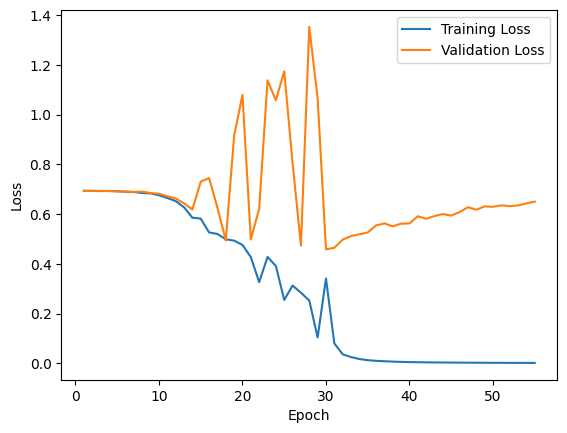

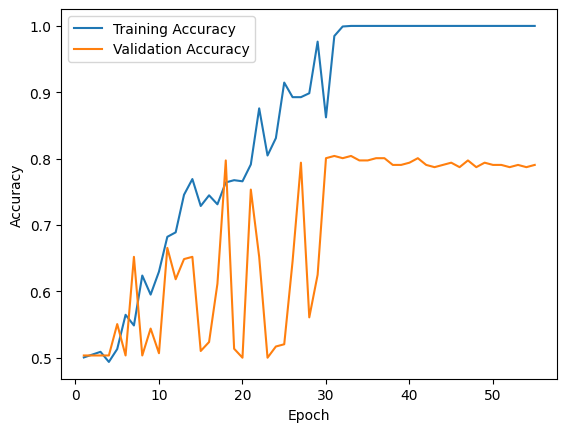

In [15]:
# Plot training and validation loss
plt.plot(range(1, num_epochs + 1), history.history['loss'], label='Training Loss')
plt.plot(range(1, num_epochs + 1), history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


# Plot training and validation accuracy
plt.plot(range(1, num_epochs + 1), history.history['accuracy'], label='Training Accuracy')
plt.plot(range(1, num_epochs + 1), history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


## Part 7. Evaluate the Model's Performance

### Improve Model's Performance and Prevent Overfitting 

Neural networks can be prone to overfitting. Notice that the training accuracy is 100% but the validation accuracy is around 80%. This indicates that our model is overfitting; it will not perform as well on new, previously unseen data as it did during training. We want to have an accurate idea of how well our model will generalize to new data. Our goal is to have our training and validation accuracy scores be as close as possible.

While there are different techniques that can be used to prevent overfitting, for the purpose of this exercise we will focus on two methods:

1. Changing the number of epochs. Too many epochs can lead to overfitting of the training dataset, whereas too few epochs may result in underfitting.

2. Adding dropout regularization. During training, the nodes of a particular layer may always become influenced only by the output of a particular node in the previous layer, causing overfitting. Dropout regularization is a technique that randomly drops a number of nodes in a neural network during training as a way of adding randomization and preventing nodes from becoming dependent on one another. Adding dropout regularization can reduce overfitting and also improve the performance of the model. 

<b>Task:</b> 

1. Tweak the variable `num_epochs` above and restart and rerun all of the cells above. Evaluate the performance of the model on the training data and the validation data.

2. Add Keras `Dropout` layers after one or all hidden layers. Add the following line of code after you add a hidden layer to your model object:  `nn_model.add(keras.layers.Dropout(.25))`. The parameter `.25` is the fraction of the nodes to drop. You can experiment with this value as well. Restart and rerun all of the cells above. Evaluate the performance of the model on the training data and the validation data.


<b>Analysis:</b> 
In the cell below, specify the different approaches you used to reduce overfitting and summarize which configuration led to the best generalization performance.

Did changing the number of epochs prevent overfitting? Which value of `num_epochs` yielded the closest training and validation accuracy score? 

Did adding dropout layers prevent overfitting? How so? Did it also improve the accuracy score when evaluating the validation data? How many dropout layers did you add and which fraction of nodes did you drop? 

Record your findings in the cell below.

Epoch [5/ 100], Loss: 0.6919, Accuracy: 0.5224, Val_loss: 0.6927, Val_accuracy: 0.4966
Epoch [10/ 100], Loss: 0.6747, Accuracy: 0.6213, Val_loss: 0.6762, Val_accuracy: 0.6554
Epoch [15/ 100], Loss: 0.5753, Accuracy: 0.7160, Val_loss: 0.5782, Val_accuracy: 0.7500
Epoch [20/ 100], Loss: 0.4818, Accuracy: 0.7844, Val_loss: 0.5336, Val_accuracy: 0.7297
Epoch [25/ 100], Loss: 0.3353, Accuracy: 0.8673, Val_loss: 0.6947, Val_accuracy: 0.6351
Epoch [30/ 100], Loss: 0.2854, Accuracy: 0.8859, Val_loss: 0.4415, Val_accuracy: 0.8041
Epoch [35/ 100], Loss: 0.0394, Accuracy: 0.9941, Val_loss: 0.5253, Val_accuracy: 0.8108
Epoch [40/ 100], Loss: 0.2765, Accuracy: 0.9062, Val_loss: 0.4667, Val_accuracy: 0.7973
Epoch [45/ 100], Loss: 0.0267, Accuracy: 0.9992, Val_loss: 0.5354, Val_accuracy: 0.7939
Epoch [50/ 100], Loss: 0.0106, Accuracy: 1.0000, Val_loss: 0.6095, Val_accuracy: 0.7838
Epoch [55/ 100], Loss: 0.0091, Accuracy: 1.0000, Val_loss: 0.6825, Val_accuracy: 0.8074
Epoch [60/ 100], Loss: 0.0086, Ac

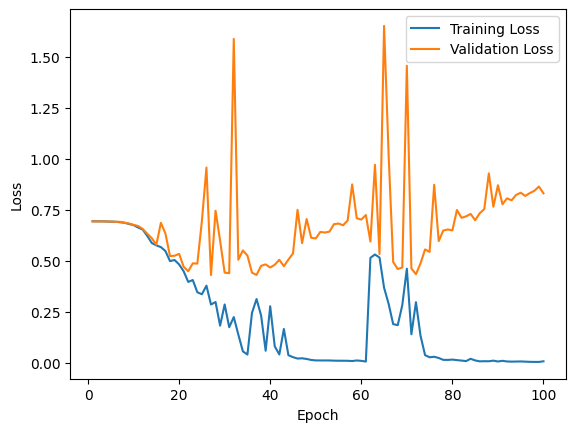

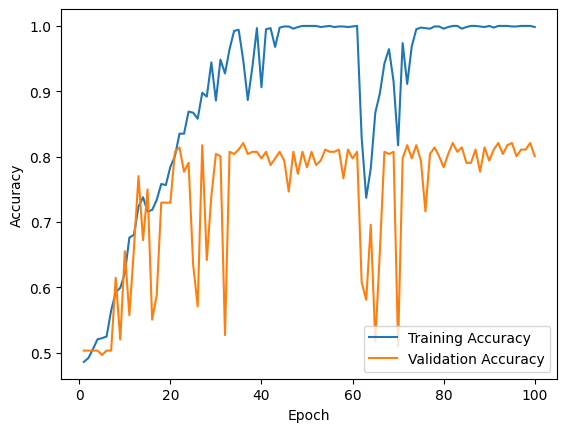

In [16]:
nn_model = keras.Sequential() # YOUR CODE HERE
nn_model.add(keras.layers.InputLayer(input_shape=vocabulary_size))
nn_model.add(keras.layers.Dense(units=64,activation='ReLU'))
nn_model.add(keras.layers.Dropout(0.2))
nn_model.add(keras.layers.Dense(units=32,activation='ReLU'))
nn_model.add(keras.layers.Dropout(0.2))
nn_model.add(keras.layers.Dense(units=16,activation='ReLU'))
nn_model.add(keras.layers.Dropout(0.2))
nn_model.add(keras.layers.Dense(units=1,activation='sigmoid'))
sgd_optimizer=keras.optimizers.SGD(learning_rate=0.1)
loss_fn=keras.losses.BinaryCrossentropy(from_logits=False)
nn_model.compile(optimizer=sgd_optimizer,loss=loss_fn,metrics=['accuracy'])
t0 = time.time() # start time
num_epochs=100

history = nn_model.fit(X_train_tfidf.toarray(),y_train,epochs=num_epochs,verbose=0,validation_split=0.2,callbacks=[ProgBarLoggerNEpochs(num_epochs, every_n=5)])# YOUR CODE HERE 
t1 = time.time() # stop time
print('Elapsed time: %.2fs' % (t1-t0))
# Plot training and validation loss
plt.plot(range(1, num_epochs + 1), history.history['loss'], label='Training Loss')
plt.plot(range(1, num_epochs + 1), history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()
# Plot training and validation accuracy
plt.plot(range(1, num_epochs + 1), history.history['accuracy'], label='Training Accuracy')
plt.plot(range(1, num_epochs + 1), history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

First, I added all the Dropout layers as specified without changing the epoch number. What resulted are the following graphs, which shows a fluctuating graph with a spike in higher training accuracy at epoch ~50, whereas the optimal validation accuracy is at around epoch ~22. 

There are big, uncharacteristic drop in both training and validation accuracy throughout the training epochs. Seeing how the graph was so volatile, I decided to lower the dropout percentage to 0.1 and experiment with epoch 30. This time, I ended up with the following metrics: \[Loss: 0.1705, Accuracy: 0.9510, Val_loss: 0.4540, Val_accuracy: 0.8108\]. These are slightly better numbers, but we still can see a dramatic increase of training accuracy. I will now try dropout rate 0.15 and epoch 40 to capture a bigger picture.

I came to the same conclusion as the first modification, which is that validation loss and accuracy are optimized around epoch 22 and does not further increase with epoch, while training metrics increase still. That's where we should stop the training process for the optimal results without overfitting. Running again with epoch 22.

Got worse. epochs=20.
Got better. epochs=30.

It seems like due to the randomness of the validation splits, the optimal number of epochs shifts around with every split and the graph remains volatile. I don't know how to resolve this issue. Decided to epochs=100. Seems like this time, training and validation metrics both stabilize after epoch 40. Let's try drop out rate 0.40 with epoch 100.

Drop out rate 0.4 resulted in large amounts of fluctuations. Now trying 0.2, which stabilized (with fluctuations) at epoch 40 with metrics \[Loss: 0.0125, Accuracy: 1.0000, Val_loss: 0.6831, Val_accuracy: 0.8041\]

In the end I decided that epoch 40 and drop out rate 0.2 are probably the best parameters for this. The graph shows different things even just by rerunning with the same parameters, and these are the most promising numbers. I will now specify that in a new model called nn_model1 because the 100 epoch fitted nn_model actually looks pretty good, and I want to evaluate both.

Epoch [5/ 100], Loss: 0.6902, Accuracy: 0.5511, Val_loss: 0.6895, Val_accuracy: 0.5034
Epoch [10/ 100], Loss: 0.6508, Accuracy: 0.6619, Val_loss: 0.6660, Val_accuracy: 0.5439
Epoch [15/ 100], Loss: 0.5396, Accuracy: 0.7278, Val_loss: 0.5168, Val_accuracy: 0.7973
Epoch [20/ 100], Loss: 0.4039, Accuracy: 0.8267, Val_loss: 0.4846, Val_accuracy: 0.7905
Epoch [25/ 100], Loss: 0.2541, Accuracy: 0.9028, Val_loss: 0.4243, Val_accuracy: 0.8142
Epoch [30/ 100], Loss: 0.2965, Accuracy: 0.9079, Val_loss: 0.4227, Val_accuracy: 0.8209
Epoch [35/ 100], Loss: 0.1654, Accuracy: 0.9603, Val_loss: 0.4981, Val_accuracy: 0.8108
Epoch [40/ 100], Loss: 0.0222, Accuracy: 0.9958, Val_loss: 0.5836, Val_accuracy: 0.7939
Elapsed time: 3.81s


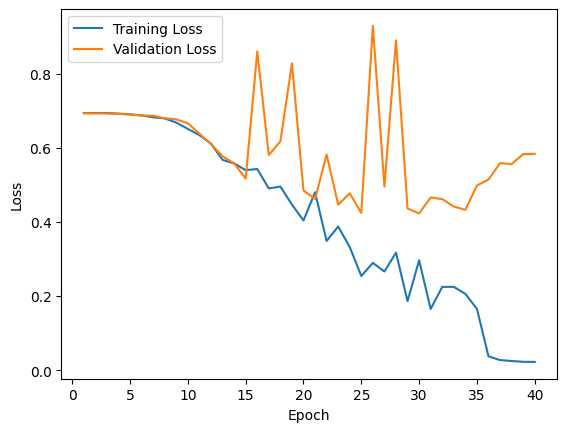

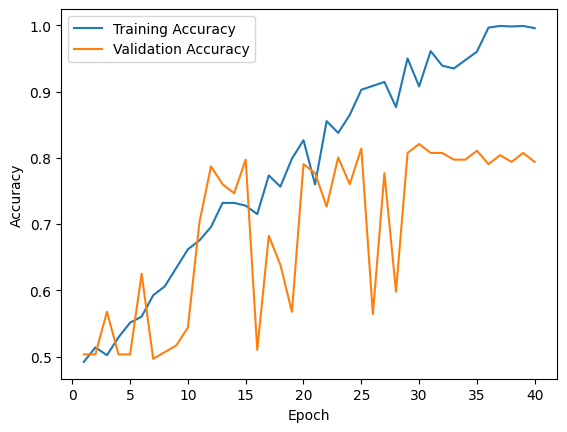

In [17]:
nn_model1 = keras.Sequential() # YOUR CODE HERE
nn_model1.add(keras.layers.InputLayer(input_shape=vocabulary_size))
nn_model1.add(keras.layers.Dense(units=64,activation='ReLU'))
nn_model1.add(keras.layers.Dropout(0.2))
nn_model1.add(keras.layers.Dense(units=32,activation='ReLU'))
nn_model1.add(keras.layers.Dropout(0.2))
nn_model1.add(keras.layers.Dense(units=16,activation='ReLU'))
nn_model1.add(keras.layers.Dropout(0.2))
nn_model1.add(keras.layers.Dense(units=1,activation='sigmoid'))
sgd_optimizer=keras.optimizers.SGD(learning_rate=0.1)
loss_fn=keras.losses.BinaryCrossentropy(from_logits=False)
nn_model1.compile(optimizer=sgd_optimizer,loss=loss_fn,metrics=['accuracy'])
t2 = time.time() # start time
num_epochs1=40

history1 = nn_model1.fit(X_train_tfidf.toarray(),y_train,epochs=num_epochs1,verbose=0,validation_split=0.2,callbacks=[ProgBarLoggerNEpochs(num_epochs, every_n=5)])# YOUR CODE HERE 
t3 = time.time() # stop time
print('Elapsed time: %.2fs' % (t3-t2))
# Plot training and validation loss
plt.plot(range(1, num_epochs1 + 1), history1.history['loss'], label='Training Loss')
plt.plot(range(1, num_epochs1 + 1), history1.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()
# Plot training and validation accuracy
plt.plot(range(1, num_epochs1 + 1), history1.history['accuracy'], label='Training Accuracy')
plt.plot(range(1, num_epochs1 + 1), history1.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

### Evaluate the Performance on the Test Set

Now that you have improved the model, let's evaluate its performance on our test data and compare the results.

<b>Task:</b> In the code cell below, call the  `evaluate()` method on the model object `nn_model`. Specify `X_test_tfidf` and `y_test` as arguments. You must convert `X_test_tfidf` to a NumPy array using the `toarray()` method. 

Note: The `evaluate()` method returns a list containing two values. The first value is the loss and the second value is the accuracy score.


In [18]:
loss, accuracy = nn_model.evaluate(X_test_tfidf.toarray(),y_test)# YOUR CODE HERE

print('Loss: ', str(loss) , 'Accuracy: ', str(accuracy))
loss, accuracy = nn_model1.evaluate(X_test_tfidf.toarray(),y_test)# YOUR CODE HERE

print('Loss: ', str(loss) , 'Accuracy: ', str(accuracy))

16/16 [==============================] - 0s 978us/step - loss: 0.7730 - accuracy: 0.8239
Loss:  0.7730020880699158 Accuracy:  0.8238866329193115
16/16 [==============================] - 0s 981us/step - loss: 0.5328 - accuracy: 0.8259
Loss:  0.5328187942504883 Accuracy:  0.8259109258651733


Seems like nn_model1 won by a mile in terms of losses.

### Make Predictions on the Test Set

Now that we have our best performing model that can generalize to new, previously unseen data, let us make predictions using our test data.

In the cell below, we will make a prediction on our test set and receive probability predictions for every example in the test set (these values will be between 0.0 and 1.0). We will then inspect the results for the first 20 examples &mdash; We will apply a threshold to determine the predicted class for every example; we will use a threshold of 0.5. This means that if the probability is greater than 0.5, we will assume the book review is good. We will then print the actual class labels contained in `y_test` to see if our model is producing accurate predictions.

<b>Task: </b> In the code cell below, do the following:

1. Call the  `predict()` method on the model object `nn_model`. Specify `X_test_tfidf` as an argument. You must convert `X_test_tfidf` to a NumPy array using the `toarray()` method. Save the results to the array `probability_predictions`.
2. Loop through the first 20 items in `probability_predictions`. These correspond to the predicted probabilities for the first 20 examples in our test set. For every item, check if the probability is greater than 0.5. If so, output:
* the probability value in `probability_predictions`
* the corresponding label in `y_test`. Note: convert the series `y_test` using `y_test.to_numpy()` before indexing into it.

Inspect the results. How is our model performing? Is our model properly predicting whether the book reviews are good or bad reviews?

In [19]:
# Make predictions on the test set
probability_predictions =nn_model1.predict(X_test_tfidf.toarray()) # YOUR CODE HERE

print("Predictions for the first 20 examples:")
# YOUR CODE HERE
y_truth = y_test.to_numpy()
arr = []
for x in range(20):
    if probability_predictions[x] > 0.5:
        arr.append((probability_predictions[x].astype(float).item(),y_truth[x]))
print(arr)

##I don't know why it's only showing 9 examples

Predictions for the first 20 examples:
[(0.9726682901382446, True), (0.9994500875473022, True), (0.9811785817146301, True), (0.6702232956886292, False), (0.995729923248291, True), (0.9964596033096313, True), (0.9988870024681091, True), (0.9981088638305664, True), (0.8225414752960205, False), (0.9430797100067139, True), (0.9961107969284058, True)]


In [20]:
print((X_test_tfidf).shape[0])

494


Let's check a few of the original book review texts to get a further glimpse into how our model is performing.

In [21]:
print('Review #1:\n')

print(X_test.to_numpy()[11])

goodReview = True if probability_predictions[11] >= .5 else False
    
print('\nPrediction: Is this a good review? {}\n'.format(goodReview))

print('Actual: Is this a good review? {}\n'.format(y_test.to_numpy()[11]))

Review #1:

I was wrong. Ok, I've admitted it. I always thought science fiction or futuristic type novels weren't my cup of tea. While reading Conspiracy in Death I realized I couldn't have been more wrong - I love this futuristic series! 

A homeless man is murdered and the case is assigned to Eve Dallas, since it's not a random act of violence. This man, Snooks, died when his heart was surgically removed by what appeared to be a very skilled surgeon. When Dallas digs a bit further, she discovers that this crime is connected to another committed in New York City where an aged LC (licensed companion) died as the result of her liver being removed. After even more digging, Dallas discovers a case in Chicago and one abroad that were all similar. 

These were not the result of black market organ sales since all of the victims were within a few months of dying. In order for Eve Dallas to find the murderer she had to figure out why these victims were chosen. The closer she got to that answer

In [22]:
print('Review #2:\n')

print(X_test.to_numpy()[24])

goodReview = True if probability_predictions[24] >= .5 else False

print('\nPrediction: Is this a good review? {}\n'.format(goodReview)) 

print('Actual: Is this a good review? {}\n'.format(y_test.to_numpy()[24]))

Review #2:

Good book on deal structure, but if you want a valuation number, check out &quot;Unlocking the Value of Your Business&quot;


Prediction: Is this a good review? True

Actual: Is this a good review? False



In [23]:
print('Review #3:\n')

print(X_test.to_numpy()[56])

goodReview = True if probability_predictions[56] >= .5 else False
    
print('\nPrediction: Is this a good review? {}\n'.format(goodReview))

print('Actual: Is this a good review? {}\n'.format(y_test.to_numpy()[56]))

Review #3:

I'm trying to figure out what the appropriate subtitle for this book should be and I can't decide among the following:

    * Travels Through Guilt with the World's 33rd Richest Hippie
    * The Mind of an Empty Suit
    * A Self-Important Revisionist History
    * How I Learned to Hate Myself and Love the Third World
    * Memoirs of a Cold War Paperpusher

Confessions of an Economic Hitman by John Perkins is an exclamation point riddled history of a few financial manipulations of the Cold War by a man who had no stake in his own ambition.

The first thing you notice about this account is that it is written by a man who thinks he was sitting on top of the world, when in fact he was just a cog in the energy industry. If you are credulous enough to believe that the debts and revenues associated with the energy business is indeed the core principle of the global economy, then the moral outrage of this book makes sense. But there's a whole lot to swallow.

On the plus side, it

In [24]:
print('Review #4:\n')
print(X_test.to_numpy()[102])

goodReview = True if probability_predictions[102] >= .5 else False
    
print('\nPrediction: Is this a good review? {}\n'.format(goodReview))

print('Actual: Is this a good review? {}\n'.format(y_test.to_numpy()[102]))

Review #4:

I'm a Zone diet believer - but this book is a serious letdown.  Two major problems with this worthless book:
1. Almost all of the recipes involve *far* too much preparation - the title is *very* misleading.
2. I find it hard to believe that anyone actually prepared these recipes, and thought they were *good*!  Most of the meals are horrible due to the *huge* proportion of vegetables.  I mean, an omelet with over 3 cups of asparagus??


Prediction: Is this a good review? False

Actual: Is this a good review? False



## Part 8: Analysis

Experiment with the vectorizer and neural network implementation above and compare your results every time you train the network. Pay attention to the time it takes to train the network, and the resulting loss and accuracy on both the training and test data. 

Below are some ideas for things you can try:

* Adjust the learning rate.
* Add more hidden layers and/or experiment with different values for the `unit` parameter in the hidden layers to change the number of nodes in the hidden layers.
* Fit your vectorizer using different document frequency values and different n-gram ranges. When creating a `TfidfVectorizer` object, use the parameter `min_df` to specify the minimum 'document frequency' and use `ngram_range=(1,2)` to change the default n-gram range of `(1,1)`.

Record your findings in the cell below.


Vocab size:  1130
Epoch [5/ 40], Loss: 0.6916, Accuracy: 0.5385, Val_loss: 0.6920, Val_accuracy: 0.5203
Epoch [10/ 40], Loss: 0.6876, Accuracy: 0.5748, Val_loss: 0.6879, Val_accuracy: 0.6182
Epoch [15/ 40], Loss: 0.6772, Accuracy: 0.6289, Val_loss: 0.6766, Val_accuracy: 0.6757
Epoch [20/ 40], Loss: 0.6451, Accuracy: 0.6889, Val_loss: 0.6439, Val_accuracy: 0.7061
Epoch [25/ 40], Loss: 0.5664, Accuracy: 0.7363, Val_loss: 0.5894, Val_accuracy: 0.6791
Epoch [30/ 40], Loss: 0.4475, Accuracy: 0.7997, Val_loss: 0.5068, Val_accuracy: 0.7365
Epoch [35/ 40], Loss: 0.4016, Accuracy: 0.8292, Val_loss: 0.4920, Val_accuracy: 0.7770
Epoch [40/ 40], Loss: 0.3740, Accuracy: 0.8478, Val_loss: 0.4953, Val_accuracy: 0.7872
Elapsed time: 2.20s


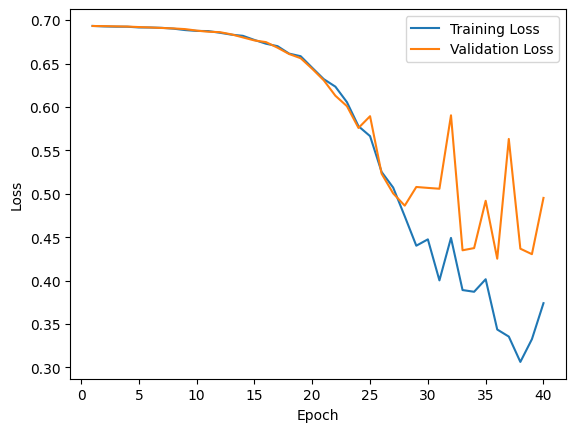

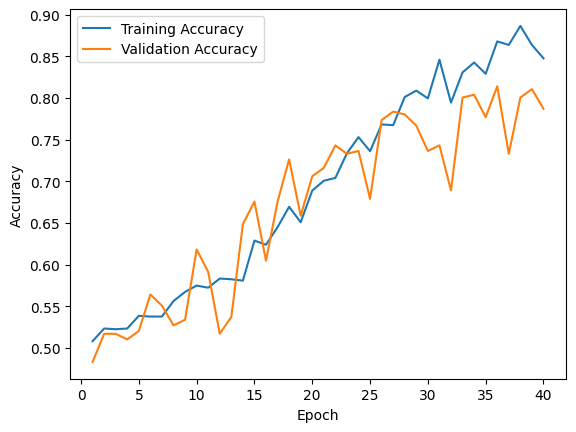

In [25]:
tfidf_vectorizer = TfidfVectorizer(min_df=0.02,ngram_range=(1,2))
tfidf_vectorizer.fit(X_train)
X_train_tfidf = tfidf_vectorizer.transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)
vocabulary_size = len(tfidf_vectorizer.vocabulary_)
print('Vocab size: ',vocabulary_size)

nn_model = keras.Sequential() # YOUR CODE HERE
nn_model.add(keras.layers.InputLayer(input_shape=vocabulary_size))
nn_model.add(keras.layers.Dense(units=128,activation='ReLU'))
nn_model.add(keras.layers.Dropout(0.2))
nn_model.add(keras.layers.Dense(units=64,activation='ReLU'))
nn_model.add(keras.layers.Dropout(0.2))
nn_model.add(keras.layers.Dense(units=32,activation='ReLU'))
nn_model.add(keras.layers.Dropout(0.2))
nn_model.add(keras.layers.Dense(units=16,activation='ReLU'))
nn_model.add(keras.layers.Dropout(0.1))
nn_model.add(keras.layers.Dense(units=1,activation='sigmoid'))
sgd_optimizer=keras.optimizers.SGD(learning_rate=0.04)
loss_fn=keras.losses.BinaryCrossentropy(from_logits=False)
nn_model.compile(optimizer=sgd_optimizer,loss=loss_fn,metrics=['accuracy'])
t0 = time.time() # start time
num_epochs=40

history = nn_model.fit(X_train_tfidf.toarray(),y_train,epochs=num_epochs,verbose=0,validation_split=0.2,callbacks=[ProgBarLoggerNEpochs(num_epochs, every_n=5)])# YOUR CODE HERE 
t1 = time.time() # stop time
print('Elapsed time: %.2fs' % (t1-t0))
# Plot training and validation loss
plt.plot(range(1, num_epochs + 1), history.history['loss'], label='Training Loss')
plt.plot(range(1, num_epochs + 1), history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()
# Plot training and validation accuracy
plt.plot(range(1, num_epochs + 1), history.history['accuracy'], label='Training Accuracy')
plt.plot(range(1, num_epochs + 1), history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

From previous experience with neural net in assignment 7(?probably), I know that too high of a learning rate will result in fluctuations. I will now half the learning rate to 0.05, ngram_range=(1,3) so that it can create Unigrams Bigrams and Trigrams, min_df=0.1 which means that a word must appear in at least 10% of the reviews so that meaningless words are not counted, learning rate = 0.04 to mitigate the volatility. And the resulting graph are these beautiful loss and accuracy plots that we are familiar with instead of the previous jagged mountains. There is no overfitting here, and  even though the accuracy is 

In [26]:
loss, accuracy = nn_model.evaluate(X_test_tfidf.toarray(),y_test)# YOUR CODE HERE

print('Loss: ', str(loss) , 'Accuracy: ', str(accuracy))

16/16 [==============================] - 0s 644us/step - loss: 0.5637 - accuracy: 0.7368
Loss:  0.5637454390525818 Accuracy:  0.7368420958518982
